In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import keras
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller
import math
import missingno as msno

from src.utils.files import get_latest_file
from src.utils.clean_data import remove_cols
from src.data.data_utils import split_sequences
from src.train.models import build_dmq_v0

import json


In [18]:
fred_app = pd.read_csv(r"C:\Users\Robpr\Downloads\FRED-MD_Appendix0324\FRED-MD Appendix\FRED-MD_updated_appendix.csv", encoding='cp1252')
fred_app.head()

,id,tcode,fred,description,gsi,gsi:description,group
0,1,5,RPI,Real Personal Income,M_14386177,PI,1
1,2,5,W875RX1,Real personal income ex transfer receipts,M_145256755,PI less transfers,1
2,3,5,DPCERA3M086SBEA,Real personal consumption expenditures,M_123008274,Real Consumption,4
3,4,5,CMRMTSPLx,Real Manu. and Trade Industries Sales,M_110156998,M&T sales,4
4,5,5,RETAILx,Retail and Food Services Sales,M_130439509,Retail sales,4


In [27]:
fred_dict = fred_app.groupby('group')['fred'].apply(list).to_dict()

In [31]:
with open('fred_group_dict.json', 'w') as f:
    json.dump(fred_dict, f, indent=4)

In [35]:
chars = pd.read_csv(
    r"C:\Users\Robpr\Downloads\cluster_labels.csv"
)
chars.head()

,characteristic,cluster
0,age,Low Leverage
1,aliq_at,Investment
2,aliq_mat,Low Leverage
3,ami_126d,Size
4,at_be,Low Leverage


In [37]:
chars_dict = chars.groupby('cluster')['characteristic'].apply(list).to_dict()
chars_dict

{'Accruals': ['cowc_gr1a',
  'oaccruals_at',
  'oaccruals_ni',
  'seas_16_20na',
  'taccruals_at',
  'taccruals_ni'],
 'Debt Issuance': ['capex_abn',
  'debt_gr3',
  'fnl_gr1a',
  'ncol_gr1a',
  'nfna_gr1a',
  'ni_ar1',
  'noa_at'],
 'Investment': ['aliq_at',
  'at_gr1',
  'be_gr1a',
  'capx_gr1',
  'capx_gr2',
  'capx_gr3',
  'coa_gr1a',
  'col_gr1a',
  'emp_gr1',
  'inv_gr1',
  'inv_gr1a',
  'lnoa_gr1a',
  'mispricing_mgmt',
  'ncoa_gr1a',
  'nncoa_gr1a',
  'noa_gr1a',
  'ppeinv_gr1a',
  'ret_60_12',
  'sale_gr1',
  'sale_gr3',
  'saleq_gr1',
  'seas_2_5na'],
 'Low Leverage': ['age',
  'aliq_mat',
  'at_be',
  'bidaskhl_21d',
  'cash_at',
  'netdebt_me',
  'ni_ivol',
  'rd_sale',
  'rd5_at',
  'tangibility',
  'z_score'],
 'Low Risk': ['beta_60m',
  'beta_dimson_21d',
  'betabab_1260d',
  'betadown_252d',
  'earnings_variability',
  'ivol_capm_21d',
  'ivol_capm_252d',
  'ivol_ff3_21d',
  'ivol_hxz4_21d',
  'ocfq_saleq_std',
  'rmax1_21d',
  'rmax5_21d',
  'rvol_21d',
  'seas_6_10na'

In [38]:
with open('jkp_chars_dict.json', 'w') as f:
    json.dump(chars_dict, f, indent=4)

In [6]:
from src.data.prepare_data import prepare_quantile_data, prepare_non_rnn_data, prepare_rnn_data

non_rnn_data, rnn_data, meta_data = prepare_quantile_data(
    target=1,
    time_steps=12,
    targets_path='./data/processed/us_4q_fred_y.csv',
    input_paths=[
        './data/processed/us_4q_fred_x.csv',
        './data/processed/us_4q_oap_vw_x_stationary.csv'
    ],
    start_date='1961-01-01',
    train_cutoff_year=1997,
    n_quantiles=5,
    val_years=2
)

X_train, X_val, X_test, t_train, t_val, t_test = prepare_non_rnn_data(
    targets_path='./data/processed/us_4q_fred_y.csv',
    input_paths=[
        './data/processed/us_4q_fred_x.csv',
        './data/processed/us_4q_oap_vw_x_stationary.csv'
    ],
    start_date='1961-01-01',
    train_cutoff_year=1997,
    val_months=24,
    test_months=12,
    val_split_style='date',
    target_scale_factor=100
)

X_train_rnn, X_val_rnn, X_test_rnn, t_train_rnn, t_val_rnn, t_test_rnn = prepare_rnn_data(
    targets_path='./data/processed/us_4q_fred_y.csv',
    input_paths=[
        './data/processed/us_4q_fred_x.csv',
        './data/processed/us_4q_oap_vw_x_stationary.csv'
    ],
    start_date='1961-01-01',
    train_cutoff_year=1997,
    val_months=24,
    test_months=12,
    val_split_style='date',
    target_scale_factor=100,
    n_timesteps=12
)

Train: 1961-01-01 to 1995-12-01 00:00:00
Validation: 1996-01-01 00:00:00 to 1997-12-01 00:00:00
Test: 1998-01-01 00:00:00 to 1998-12-01 00:00:00


In [ ]:
@keras.saving.register_keras_serializable()
class BlockDiagonal(keras.layers.Layer):

    """
    Block diagonal layer that takes an entire feature vector of dimension 
    input_dim and splits it into num_heads each with dimension 
    head_dim = input_dim // num_heads. Then, each head performs a linear
    projection along the head_dim outputing a tensor of shape 
    (batch, num_heads, head_dim) 
    """

    def __init__(
            self, 
            num_heads,
            units,
            kernel_initializer='glorot_uniform',
            kernel_regularizer=None, 
            use_bias=False,
            **kwargs
        ):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.units = units
        self.kernel_initializer = kernel_initializer
        self.kernel_regularizer = kernel_regularizer
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]

        if self.units % self.num_heads != 0:
            raise ValueError(
                (
                    f'The hidden units {self.units} is not divisible' 
                    f'by the number of heads {self.num_heads}.'
                 )
            )
        
        self.padded_features = (
            math.ceil(input_dim / self.num_heads) 
            * self.num_heads
            )
        self.pad_size = self.padded_features - input_dim

        if self.pad_size != 0:
            print(
                f"""
                Number of features is not divisible by the number of heads.
                Padding features with {self.pad_size} zeros.
                """
            )

        self.padded_input_dim = input_dim + self.pad_size

        self.head_dim = self.padded_input_dim // self.num_heads

        self.W = self.add_weight( 
            shape=(self.num_heads, self.units, self.head_dim),
            initializer=self.kernel_initializer,
            regularizer=self.kernel_regularizer,
            name='weights'
        )

        if self.use_bias:
            self.b = self.add_weight(
                shape=(self.num_heads, self.units)
            )
        else:
            self.b = None

    def call(self, x):
        # x comes in the shape (batch, input_dim) but we want (batch, num_heads, head_dim)
        shape = keras.ops.shape(x)
        batch = shape[0]
        features = shape[1]

        if self.pad_size > 0:
            # pad the feature dimension
            x = keras.ops.pad(x, [[0, 0], [0, self.pad_size]])
        
        # print(f'Input shape: {keras.ops.shape(x)}')
        # print(f'Desired shape: {(batch, self.num_heads, self.head_dim)}')
        
        # Partition the input
        # Note this requires that the number of features is evenly divisible 
        # by the number of heads
        x =  keras.ops.reshape(
            x, 
            (batch, self.num_heads, self.head_dim)
        )
        
        # Einstein sum as an efficient alternative to Block diagonal matrix
        #  multiplication. Equivalent to multiplying each weight matrix by the
        #  corresponding input subset (along dimension j)
        # Doing this for the whole batch results in shape 
        # (batch, num_heads, units). Bias broadcasts across batch
        y = keras.ops.einsum("nuh,bnh->bnu", self.W, x)
        if self.use_bias:
            y = y + self.b

        return y
    
    def get_config(self):
        config = super().get_config()
        config.update(
            {
                'num_heads': self.num_heads,
                'units': self.units,
                'use_bias': self.use_bias,
                'kernel_initializer': self.kernel_initializer,
                'kernel_regularizer': self.kernel_regularizer
            }
        )
        return config

@keras.saving.register_keras_serializable()   
class MultiHeadSLSTMCell(keras.layers.Layer):
    def __init__(
            self, 
            units, 
            num_heads,
            kernel_initializer="glorot_uniform",
            recurrent_initializer='orthogonal', 
            recurrent_regularizer=None,
            kernel_regularizer=None,
            **kwargs
        ):
        super().__init__(**kwargs)
        self.units = units
        self.num_heads = num_heads
        self.head_size = self.units // self.num_heads
        self.state_size = (self.units, self.units, self.units, self.units)
        self.kernel_initializer = kernel_initializer
        self.recurrent_initializer = recurrent_initializer
        self.kernel_regularizer = kernel_regularizer
        self.recurrent_regularizer = recurrent_regularizer
        
        self.input_block = BlockDiagonal(
            num_heads, 
            4 * self.head_size, 
            kernel_initializer=kernel_initializer,
            kernel_regularizer=kernel_regularizer,
            use_bias=False
        )
        self.recurrent_block = BlockDiagonal(
            num_heads, 
            4 * self.head_size,
            kernel_initializer=recurrent_initializer,
            kernel_regularizer=recurrent_regularizer,
            use_bias=False
        )


    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.input_block.build(input_shape) # Build blocks for model.summary()

        recurrent_shape = (None, self.units)
        self.recurrent_block.build(recurrent_shape)

        # Initialize bias. Weights are initialized within BlockDiagonal
        self.biases = self.add_weight(
            shape=(self.num_heads, 4 * self.head_size),
            initializer='zeros',
            name='biases'
        )

        # sets self.built=True so build is not called on every forward pass
        super().build(input_shape) 
    
    def call(self, inputs, states):
        
        # inputs are shape (batch, input_size)
        # print(f'input shape: {inputs.shape}')
        # print(f'h shape: {states[0].shape}')

        # Each state is shape (batch, units)
        h_prev, c_prev, n_prev, m_prev = states 

        # print(f'Wx shape: {self.input_block(inputs).shape}')
        # print(f'Rh shape: {self.recurrent_block(h_prev).shape}')
        # print(f'b shape: {self.biases.shape}')
        # preactivation. returns (batch, num_heads, 4 * (units // num_heads))
        z = (
            self.input_block(inputs) + 
            self.recurrent_block(h_prev) + 
            self.biases
        )

        # Reshape each state to (num_heads, head_size)
        h_prev =  keras.ops.reshape(
            h_prev, 
            (-1, self.num_heads, self.head_size),
        )
        c_prev =  keras.ops.reshape(
            c_prev, 
            (-1, self.num_heads, self.head_size),
        )
        n_prev =  keras.ops.reshape(
            n_prev, 
            (-1, self.num_heads, self.head_size)
        )
        m_prev =  keras.ops.reshape(
            m_prev, 
            (-1, self.num_heads, self.head_size)
        )

        # Splits pre-activation into one tensor of shape
        #  (batch, num_heads, head_size) for each gate
        i_candidate, f_candidate, z_candidate, o_candidate = tf.split(
            z, 
            num_or_size_splits=4, 
            axis=2
        )

        # Main sLSTM math
        logfplusm =  keras.ops.log_sigmoid(f_candidate) + m_prev

        m = keras.ops.cond(
            keras.ops.all(
                keras.ops.equal(n_prev, 0.0)
            ),
            lambda: i_candidate,
            lambda: keras.ops.maximum(i_candidate, logfplusm),
        )
        
        # usual output gate and cell state candidate
        o =  keras.ops.sigmoid(o_candidate)
        z =  keras.ops.tanh(z_candidate)

        # Stabilized input and foreget gates
        i = keras.ops.minimum( 
            keras.ops.exp(i_candidate - m),  
            keras.ops.ones_like(i_candidate)
        )
        f =  keras.ops.minimum( 
            keras.ops.exp(logfplusm - m),  
            keras.ops.ones_like(i_candidate)
        )
        
        c = f * c_prev + i * z
        n = f * n_prev + i
        h = o * c / n

        # Reshape states back to original shape (batch, units)
        h =  keras.ops.reshape(
            h, 
            (-1, self.num_heads*self.head_size) 
        )
        c =  keras.ops.reshape(
            c, 
            (-1, self.num_heads*self.head_size)
        )
        n =  keras.ops.reshape(
            n, 
            (-1, self.num_heads*self.head_size) 
        )
        m =  keras.ops.reshape(
            m, 
            (-1, self.num_heads*self.head_size)
        )
        
        return h, [h, c, n, m]
    
    def get_config(self):
        config = super().get_config()
        config.update(
            {
                'units': self.units,
                'num_heads': self.num_heads,
                'kernel_initializer': self.kernel_initializer,
                'recurrent_initializer': self.recurrent_initializer,
                'kernel_regularizer': self.kernel_regularizer,
                'recurrent_regularizer': self.recurrent_regularizer,
            }
        )
        return config

@keras.saving.register_keras_serializable()
class sLSTMBlock(keras.layers.Layer):

    def __init__(
        self,
        units,
        num_heads,
        return_sequences=False,
        kernel_regularizer=None,
        recurrent_regularizer=None,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.units = units
        self.num_heads = num_heads
        self.return_sequnces = return_sequences
        self.kernel_regularizer = kernel_regularizer
        self.recurrent_regularizer = recurrent_regularizer

        self.input_proj = keras.layers.Dense(
            units=units,
            name=f'{self.name}_input_proj'
        )

        self.ln1 = keras.layers.LayerNormalization(name=f'{self.name}_ln1')
        self.slstm = keras.layers.RNN(
            MultiHeadSLSTMCell(
                units=units,
                num_heads=num_heads,
                kernel_regularizer=kernel_regularizer,
                recurrent_regularizer=recurrent_regularizer
            ),
            return_sequences=return_sequences,
            name=f'{self.name}_slstm'
        )
        self.gn = keras.layers.GroupNormalization(
            groups=num_heads,
            name=f'{self.name}_gn'
        )
        self.add1 = keras.layers.Add(name=f'{self.name}_add1')

        self.ln2 = keras.layers.LayerNormalization(name=f'{self.name}_ln2')

        self.up_proj_left = keras.layers.Dense(
            units=int(4*units/3), 
            kernel_regularizer=kernel_regularizer,
            name=f'{self.name}_up_proj_left'
        )
        self.up_proj_right = keras.layers.Dense(
            units=int(4*units/3),
            kernel_regularizer=kernel_regularizer,
            name=f'{self.name}_up_proj_right'
        )

        self.gelu = keras.layers.Activation('gelu', name=f'{self.name}_gelu')
        self.mult = keras.layers.Multiply(name=f'{self.name}_mult')

        self.down_proj = keras.layers.Dense(
            units=units,
            kernel_regularizer=kernel_regularizer,
            name=f'{self.name}_down_proj'
        )
        self.add2 = keras.layers.Add(name=f'{self.name}_add2')


    def call(self, inputs):

        time_steps = inputs.shape[1]
        features = inputs.shape[2]
        batch_size = keras.ops.shape(inputs)[0]

        # print(f'inputs shape: {(batch_size, time_steps, features)}')

        if not self.return_sequnces:
            # fuse time dimension into features 
            reshaped_inputs = keras.ops.reshape(
                inputs, 
                (batch_size,time_steps*features)
            )
            x_in = self.input_proj(reshaped_inputs) # (batch, units)
        else:
            x_in = self.input_proj(inputs) # (batch, time_steps, units)

        x = self.ln1(inputs)
        x = self.slstm(x) # (batch, units) or (batch, time_steps, units)
        x = self.gn(x)
        x = self.add1([x,x_in]) # (batch, units) or (batch, time_steps, units)

        y = self.ln2(x)

        y_l = self.up_proj_left(y)
        y_r = self.up_proj_right(y)
        y_r = self.gelu(y_r)
        y = self.mult([y_l,y_r]) 
        y = self.down_proj(y) # (batch, time_steps, units) if return seq

        y = self.add2([y,x]) # (batch, time_steps, units) if return seq

        return y
    
    def get_config(self):
        config = super().get_config()

        config.update(
            {
                'units': self.units,
                'num_heads': self.num_heads,
                'return_sequences': self.return_sequnces,
                'kernel_regularizer': self.kernel_regularizer,
                'recurrent_regularizer': self.recurrent_regularizer
            }
        )

        return config

def generate_data(n_samples, num_heads=2,n_features=4):

    assert n_features % num_heads == 0
    np.random.seed(1)
    head_dim = n_features // num_heads
    X = np.random.randn(n_samples, n_features).reshape(n_samples, num_heads, head_dim)
    W_true = np.ones((num_heads, head_dim))
    
    y = np.einsum('nhi,hi->n', X, W_true)

    return X, y


### Test block diagonal layer 

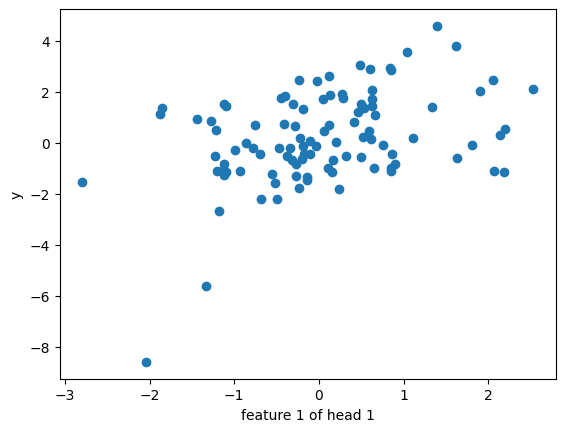

In [ ]:
import matplotlib.pyplot as plt

X, y = generate_data(n_samples=100)

plt.scatter(X[:,0, 0], y)
plt.xlabel('feature 1 of head 1')
plt.ylabel('y')
plt.show()

In [ ]:
# Make a simple neural network
model = keras.models.Sequential()
model.add(BlockDiagonal(num_heads=2, units=1))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1))
model.compile(optimizer='sgd', loss='mse')

model.fit(X.reshape(X.shape[0], -1), y, epochs=100, batch_size=4)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3747  
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7058 
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1751 
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0325 
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7401e-04 
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0508e-05 
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6364e-05 
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.3558e-06 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.3628e-06 
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2528e-06 
Epoch 13/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4911e-07 
Epoch 14/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6431e-07 
Epoch 15/100
25/25 ━━━━━

In [ ]:
y_pred = model.predict(X.reshape(X.shape[0], -1))

print(f"MSE: {np.sum(y_pred - y)**2}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
MSE: 4.795811098520755e-09


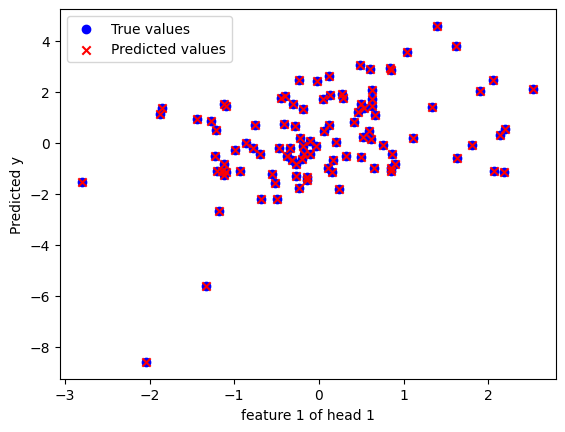

In [ ]:
plt.scatter(X[:,0, 0], y, c='blue', label='True values')
plt.scatter(X[:,0, 0], y_pred, c='red', marker='x', label='Predicted values')
plt.xlabel('feature 1 of head 1')
plt.ylabel('Predicted y')
plt.legend()
plt.show()

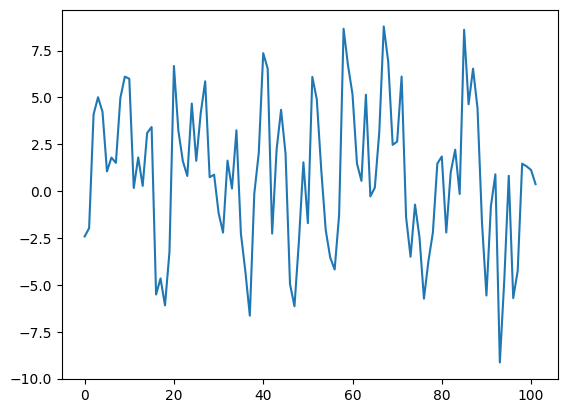

In [ ]:
timesteps = 3
features = 21
n_samples = 100 + (timesteps-1) # Buffer for resulting NaNs from lags

def generate_timeseries(n_samples, n_timesteps, n_features, seed=1):

    np.random.seed(seed)

    X_0 = np.random.randn(n_samples,n_features)
    X = X_0.copy()
    for i in range(1, n_timesteps):
        X_i = np.roll(X_0, shift=i, axis=0)
        X = np.column_stack([X,X_i])

    true_W = np.linspace(0.9, 0.01, features*timesteps).reshape(-1,1)
    y = X @ true_W  

    return X_0, y

X_0, y = generate_timeseries(
    n_samples=n_samples, 
    n_timesteps=timesteps,
    n_features=features
)
time = np.arange(X_0.shape[0])
plt.plot(time, y.flatten())
plt.show()

data = np.column_stack([X_0, y])
X_rnn, y_rnn = split_sequences(data, n_timesteps=3, n_targets=1)

In [ ]:
model = keras.models.Sequential()
model.add(
    keras.layers.RNN(
        MultiHeadSLSTMCell(
            units=8,
            num_heads=2
        ),
        return_sequences=False
    )
)
model.add(keras.layers.Dense(1))
model.compile(optimizer='sgd', loss='mse')

In [ ]:
# 2 heads
# Each head has one preactivation with input matrix W and recurrent matrix R
# and bias b
# W is shape (num_heads, num_gates*(units//num_heads), features//num_heads)
#   in this case (2,16,10)
# R is shape (num_heads, num_gates*(units//num_heads), units//num_heads)
#   in this case (2,16,4)
# b is shape (num_heads, num_gates*(units//num_heads))
#   in this case (2, 16)
# Total parameters = 2*16*10 + 2*16*4 + 2*16 = 480 
model.build(input_shape=(None,None,20))
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_6 (RNN)                     │ (None, 8)              │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489 (1.91 KB)

 Trainable params: 489 (1.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
keras.utils.plot_model(model, 'model.png')

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [ ]:
model.fit(X_rnn, y_rnn, epochs=100, batch_size=8)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.8768
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.1108
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.4696 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.8388
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.1499
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.4265 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.6028 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.6733  
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.7275 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8514 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9359 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0837 
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3741 
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7467 
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


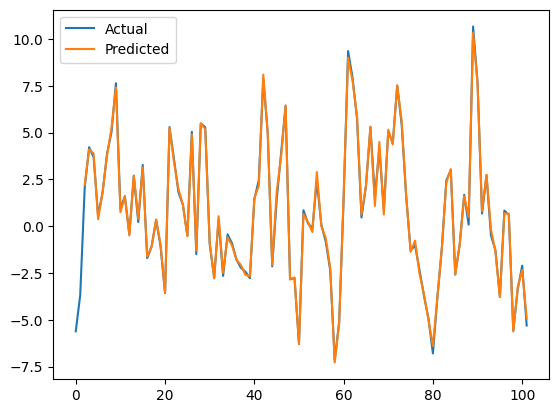

In [ ]:
predictions = model.predict(X_rnn)

plt.plot(time, y, label='Actual')
plt.plot(time[-predictions.shape[0]:], predictions[:,0], label='Predicted')
plt.legend()
plt.show()

Epoch 1/100
inputs shape: (4, 3, 21)

                Number of features is not divisible by the number of heads.
                Padding features with 1 zeros.
                
inputs shape: (4, 3, 21)
inputs shape: (4, 3, 8)
inputs shape: (4, 3, 8)
inputs shape: (4, 3, 21)
inputs shape: (4, 3, 8)
inputs shape: (4, 3, 21)
inputs shape: (4, 3, 8)
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 20.1005
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5088
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7780
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0495
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9145
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4806
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4412
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3288
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2673
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3067
E

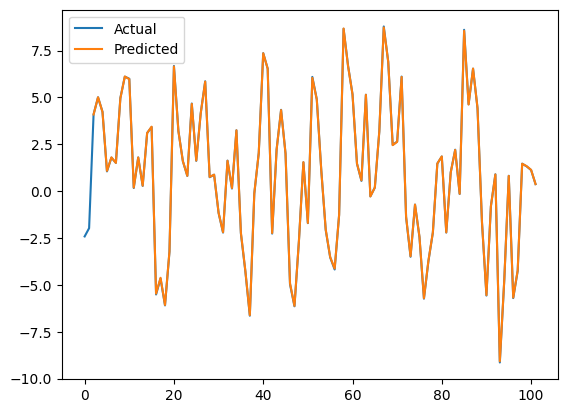

In [11]:
model = keras.models.Sequential()
model.add(
    sLSTMBlock(
        units=8,
        num_heads=2,
        kernel_regularizer=keras.regularizers.L2(0.001),
        recurrent_regularizer=keras.regularizers.L2(0.001),
        return_sequences=True
    )
)
model.add(
    sLSTMBlock(
        units=8,
        num_heads=2,
        kernel_regularizer=keras.regularizers.L2(0.001),
        recurrent_regularizer=keras.regularizers.L2(0.001)
    )
)
model.add(keras.layers.Dense(1))
model.compile(optimizer='sgd', loss='mse')

model.fit(X_rnn, y_rnn, epochs=100, batch_size=4)
predictions = model.predict(X_rnn)

plt.plot(time, y, label='Actual')
plt.plot(time[-predictions.shape[0]:], predictions[:,0], label='Predicted')
plt.legend()
plt.show()

In [104]:
4 * 2 * (21 // 2)

80

In [102]:
4 * 2 * 22

176

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


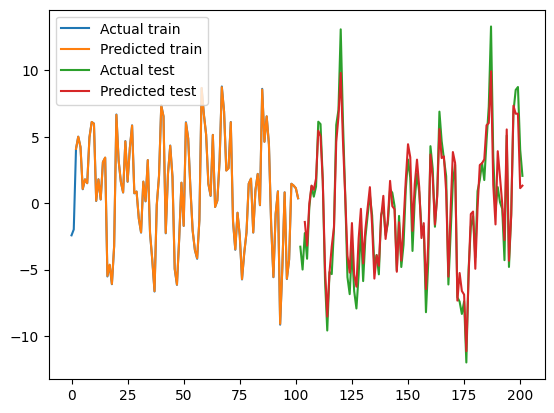

In [13]:
# Test data
X_test, y_test = generate_timeseries(100, 3, 21, seed=2)

X_test_rnn, y_test_rnn = split_sequences(
    data=np.column_stack([X_test, y_test]),
    n_timesteps=3,
    n_targets=1
)

test_pred = model.predict(X_test_rnn)

test_time = np.arange(X_0.shape[0], X_0.shape[0] + X_test.shape[0])
plt.plot(time, y, label='Actual train')
plt.plot(time[-predictions.shape[0]:], predictions[:,0], label='Predicted train')
plt.plot(test_time, y_test, label='Actual test')
plt.plot(test_time[-test_pred[:,0].shape[0]:], test_pred[:,0], label='Predicted test')
plt.legend()
plt.show()

c:\Users\Robpr\Documents\projects\macroatrisk\.venv\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 's_lstm_block_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Robpr\Documents\projects\macroatrisk\.venv\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 's_lstm_block_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


inputs shape: (4, 3, 21)

                Number of features is not divisible by the number of heads.
                Padding features with 1 zeros.
                
inputs shape: (4, 3, 21)
inputs shape: (4, 3, 8)
inputs shape: (4, 3, 21)
inputs shape: (4, 3, 8)
inputs shape: (32, 3, 21)
inputs shape: (32, 3, 8)
1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/stepinputs shape: (<tf.Tensor 'sequential_3_1/s_lstm_block_6_1/strided_slice:0' shape=() dtype=int32>, 3, 21)
inputs shape: (<tf.Tensor 'sequential_3_1/s_lstm_block_7_1/strided_slice:0' shape=() dtype=int32>, 3, 8)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step


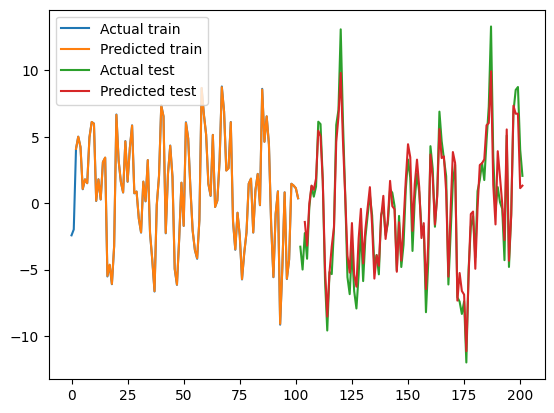

In [14]:
# Test model saving
model.save('model.keras')

# test model loading
model = keras.models.load_model('model.keras')

test_pred = model.predict(X_test_rnn)

test_time = np.arange(X_0.shape[0], X_0.shape[0] + X_test.shape[0])
plt.plot(time, y, label='Actual train')
plt.plot(time[-predictions.shape[0]:], predictions[:,0], label='Predicted train')
plt.plot(test_time, y_test, label='Actual test')
plt.plot(test_time[-test_pred[:,0].shape[0]:], test_pred[:,0], label='Predicted test')
plt.legend()
plt.show()

## Testing DMQ on synthetic data

In [ ]:
from data.prepare_data import prepare_quantile_data

target_path = './data/processed/us_4q_fred_y.csv'
input_paths = ['./data/processed/us_4q_fred_x.csv']

# Prepare data (including RNN sequences)
non_rnn_data, rnn_data, meta_data = prepare_quantile_data(
    target=0,
    time_steps=12,
    targets_path=target_path,
    input_paths=input_paths,
    start_date='1961-01-01',
    train_cutoff_year='1997',
    n_quantiles=5,
    val_years=5
)

X_train_full = non_rnn_data['X_train_full']

# Extract RNN data for training and testing
y_train_rnn = rnn_data['mq_y_train_rnn']
y_val_rnn = rnn_data['mq_y_val_rnn']
y_train_full_rnn = rnn_data['mq_y_train_full_rnn']
y_test_rnn = rnn_data['mq_y_test_rnn']
all_y_test_full = non_rnn_data['all_y_test_full']  # Assuming this is the full test set of true values for evaluation
X_train_rnn = rnn_data['X_train_rnn']
X_val_rnn = rnn_data['X_val_rnn']
X_train_full_rnn = rnn_data['X_train_full_rnn']
X_test_rnn = rnn_data['X_test_rnn']
X_test_rnn_full = rnn_data['X_test_rnn_full']

print(f"Training data shape: {X_train_rnn.shape}")
print(f"Validation data shape: {X_val_rnn.shape}")
print(f"Test data shape: {X_test_rnn.shape}")

Train: 1961-01-01 to 1992-12-01 00:00:00
Validation: 1993-01-01 00:00:00 to 1997-12-01 00:00:00
Test: 1998-01-01 00:00:00 to 1998-12-01 00:00:00
Training data shape: (373, 12, 123)
Validation data shape: (60, 12, 123)
Test data shape: (12, 12, 123)


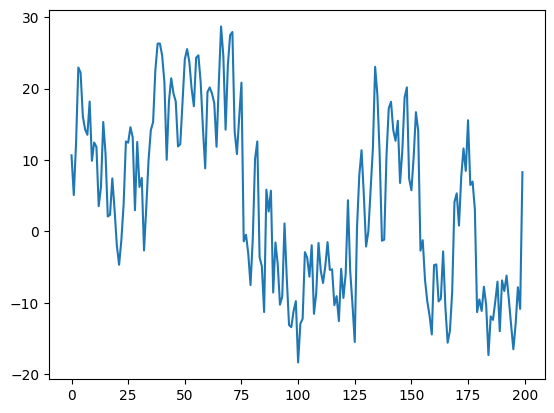

In [ ]:
def generate_synthetic_ts(
        n_samples=200,
        n_timesteps=36,
        n_features=6,
        noise_std=1.0,
        horizon=12,
        ar_coef=0.7,
        seed=1
    ):
    rng = np.random.default_rng(seed)
    total = n_samples + horizon + n_timesteps

    # AR(1) features with temporal structure
    X = np.zeros((total, n_features))
    X[0] = rng.standard_normal(n_features)
    for t in range(1, total):
        X[t] = (
            ar_coef * X[t-1] + np.sqrt(1 - ar_coef**2) 
            * rng.standard_normal(n_features)
        )
    
    # Build lagged feature matrix without roll (no boundary wrap)
    X_features = np.column_stack(
        [X[n_timesteps - i: total - i] for i in range(n_timesteps + 1)]
    )
    # X_features[t] = [X[t], X[t-1], ..., X[t-n_timesteps]], shape: (n_samples+horizon, n_features*(n_timesteps+1))

    # y is a function of X horizon steps ahead
    true_W = rng.standard_normal(X_features.shape[1])
    signal = X_features[horizon:] @ true_W          # y[t] depends on X[t+horizon], ..., X[t+horizon-n_timesteps]
    # signal = signal / signal.std()
    noise = noise_std * rng.standard_normal(n_samples)
    y = signal + noise

    X_out = X_features[:n_samples]                  # X_out[t] is available at time t (lagged features)

    return X_out, y

X, y = generate_synthetic_ts(
    n_samples=200,
    n_timesteps=36,
    n_features=6,
    ar_coef=0.9
)

time = np.arange(y.shape[0])
plt.plot(time, y)
plt.show()

In [20]:
y.shape, X.shape

((200,), (200, 222))

In [47]:
# Create data for RNN
n_timesteps = 12
X_rnn, y_rnn = split_sequences(
    data=np.column_stack([X,y]), 
    n_timesteps=n_timesteps, 
    n_targets=1
    )

y_rnn_quantile = np.repeat(y_rnn, repeats=5, axis=1)

In [49]:
X_rnn.shape, y_rnn_quantile.shape

((189, 12, 222), (189, 5))

In [61]:
n_train = 100
n_val = 0
buffer= n_timesteps-1
X_train, y_train = X_rnn[:n_train], y_rnn_quantile[:n_train]
X_val, y_val = X_rnn[(n_train):(n_train+n_val)], y_rnn_quantile[n_train:(n_train+n_val)]
X_test, y_test = X_rnn[(n_train+n_val):], y_rnn_quantile[(n_train+n_val):]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(100, 12, 222) (100, 5)
(0, 12, 222) (0, 5)
(89, 12, 222) (89, 5)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - loss: 6.2333
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.7630
Epoch 3/100
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 4.7384

c:\Users\Robpr\Documents\projects\macroatrisk\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.6282
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.5258
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.4350
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.3512
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.2754
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5.2039
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.1377
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.0607
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9562
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.8688
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 4.7952
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 4.7214
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.6318
Epoch 16/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 4.5506
Epoch 17/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 4.4726
Epoch 18/100
4/4 ━━━━━━━━━━━━

KeyError: 'val_loss'

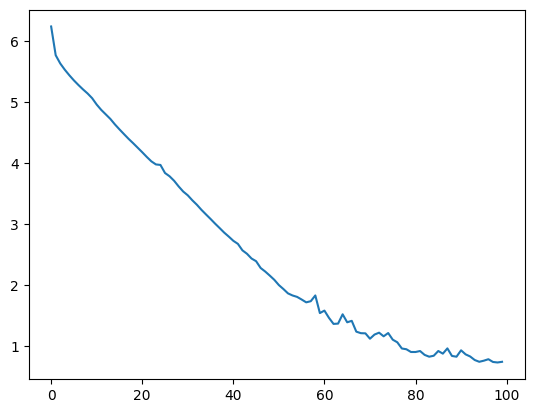

In [62]:

builder_params = {
    'input_shape': X_rnn.shape[1:],
    'n_recurrent_layers': 1, # Number of stacked slstm blocks
    'num_heads': 4,
    'n_shared_layers': 1, # No effect with slstm block
    'n_qtask_layers': 1,
    'n_recurrent_nodes': 16,
    'n_shared_nodes': 16,
    'n_task_nodes': 16,
    'recurrent_layer_type': 'slstm_block',
    'norm_fn': 'layer',
    'recurrent_norm': True,
    'shared_norm': True,
    'task_norm': True,
}

hps = {
    'l2': 0.0,
    'l1': 0.0,
    'lr': 0.001
}
builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    shuffle=False
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step


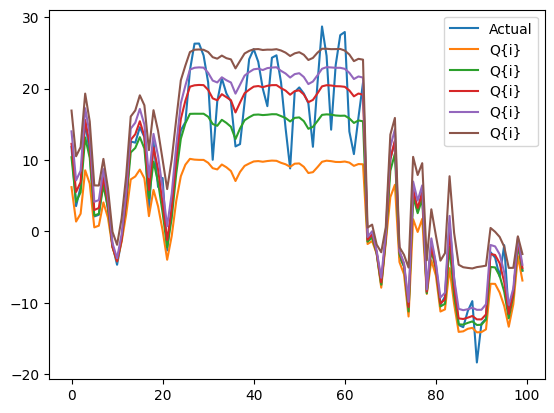

In [63]:
train_preds = model.predict(X_train)
time = np.arange(y_train.shape[0])
plt.plot(time, y_train[:,0], label='Actual')
for i in range(train_preds.shape[1]):
    plt.plot(time, train_preds[:,i], label='Q{i}')
plt.legend()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


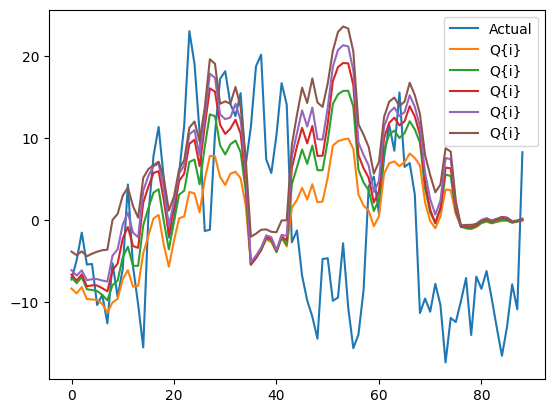

In [64]:
test_pred = model.predict(X_test)
time = np.arange(y_test.shape[0])
plt.plot(time, y_test[:,0], label='Actual')
for i in range(test_pred.shape[1]):
    plt.plot(time, test_pred[:,i], label='Q{i}')
plt.legend()
plt.show()

## Testing on real data

In [ ]:
from data.prepare_data import prepare_quantile_data

target_path = './data/processed/us_4q_fred_y.csv'
input_paths = ['./data/processed/us_4q_fred_x.csv']

# Prepare data (including RNN sequences)
non_rnn_data, rnn_data, meta_data = prepare_quantile_data(
    target=0,
    time_steps=12,
    targets_path=target_path,
    input_paths=input_paths,
    start_date='1961-01-01',
    train_cutoff_year='1997',
    n_quantiles=5,
    val_years=5
)

# Extract RNN data for training and testing
y_train_rnn = rnn_data['mq_y_train_rnn']
y_val_rnn = rnn_data['mq_y_val_rnn']
y_train_full_rnn = rnn_data['mq_y_train_full_rnn']
y_test_rnn = rnn_data['mq_y_test_rnn']
all_y_test_full = non_rnn_data['all_y_test_full']  # Assuming this is the full test set of true values for evaluation
X_train_rnn = rnn_data['X_train_rnn']
X_val_rnn = rnn_data['X_val_rnn']
X_train_full_rnn = rnn_data['X_train_full_rnn']
X_test_rnn = rnn_data['X_test_rnn']
X_test_rnn_full = rnn_data['X_test_rnn_full']

print(f"Training data shape: {X_train_rnn.shape}")
print(f"Validation data shape: {X_val_rnn.shape}")
print(f"Test data shape: {X_test_rnn.shape}")

Train: 1961-01-01 to 1992-12-01 00:00:00
Validation: 1993-01-01 00:00:00 to 1997-12-01 00:00:00
Test: 1998-01-01 00:00:00 to 1998-12-01 00:00:00
Training data shape: (373, 12, 123)
Validation data shape: (60, 12, 123)
Test data shape: (12, 12, 123)


In [9]:
pred

array([-0.13050006, -0.01109847,  0.02970699,  0.07288441,  0.07593161],
      dtype=float32)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - loss: 1.1026
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.5236
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0208
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0236
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0537
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0773
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0460
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0219
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0575
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0585
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0488
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0428
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0371
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0251
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0271
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━

KeyError: 'val_loss'

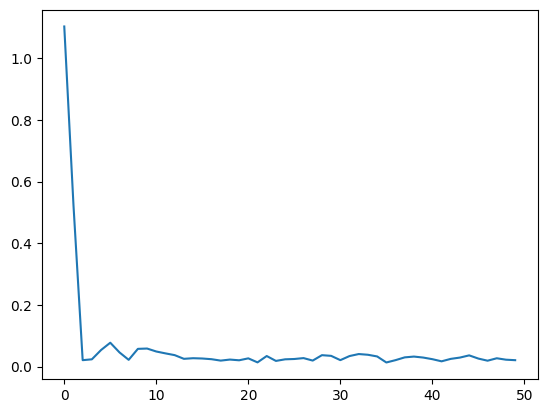

In [ ]:

subset_size = 1
X_tr = X_train_rnn[:subset_size]
y_tr = y_train_rnn[:subset_size]

builder_params = {
    'input_shape': X_tr.shape[1:],
    'n_recurrent_layers': 2, # Number of stacked slstm blocks
    'num_heads': 8,
    'n_shared_layers': 2, # No effect with slstm block
    'n_qtask_layers': 2,
    'n_recurrent_nodes': 64,
    'n_shared_nodes': 64,
    'n_task_nodes': 64,
    'recurrent_layer_type': 'slstm_block',
    'norm_fn': 'layer',
    'recurrent_norm': True,
    'shared_norm': True,
    'task_norm': True,
}

hps = {
    'l2': 0.0,
    'l1': 0.0,
    'lr': 0.001
}
builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)

history = model.fit(
    X_tr,
    y_tr,
    epochs=50,
    batch_size=X_tr.shape[0],
    # validation_data=(X_val_rnn, y_val_rnn),
    verbose=1,
    shuffle=False
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
(1,) (1,) (1, 5)


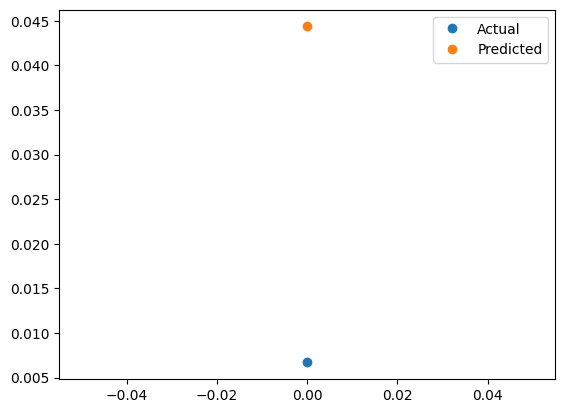

In [14]:
import numpy as np 
time = np.arange(X_tr.shape[0])
actual = y_tr[:,0]
pred = model.predict(X_tr)
r2_pred = np.mean(pred)
print(time.shape, actual.shape, pred.shape)

plt.plot(time, actual, 'o', label='Actual')
plt.plot(time, r2_pred, 'o', label='Predicted')
plt.legend()
plt.show()